**Quantum circuit simulation**

This program simulates a stock portfolio using the quantum oscillator model, and plots variance versus z. It also performs two convergence tests, one based on estimates of the quadratic coefficient, the other a direct measure of convergence to q-variance using random portfolios.

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import poisson, norm
from math import factorial

# -----------------------------------------
# Parameters
# -----------------------------------------

N = 50              # oscillator Hilbert dimension
sigma = 0.259          # long-run volatility
s_log = 0.5  #0.7            # SD(log Sigma^2)  0.5 gives good match to long-term CV
eta = 0.5 # 1  # eta<1 reduces degrees of freedom in variance measurement over period due to fat tails and correlations

lam = 0.5           # Poisson parameter

#n_days_vec = np.round(np.random.uniform(4902, 15864, 401)).astype(int)  # varies over same range as SP500 data
n_days_vec = np.array([15575,  9834, 11248,  6233,  9792, 11058,  8457, 10901,  6654, 11216, 6662,  7885,  7186,  6342, 11651,  8144,  5504,  5506, 15480,  7296, 7065, 14233, 13042, 12677,  7066,  5217,  9745, 10411,  8353, 10926, 11014, 10984, 11115, 11004,  7387, 10857,  9585,  5606, 10310,  9537, 9935, 11173,  8661,  7824, 12529,  6194,  9471, 12376, 12184, 10689, 12800,  9853,  8466,  8439,  6698,     0, 15436,  6818,  8319, 12973,  8524,  5207,  6217,  7197,  7146,  9444,  7900, 12631,  7854,  9920, 9380, 15441,  5505,  7721,  6133, 14559,  5244,  6503,  9322, 15359, 5136,  8171, 10096, 10811, 10587,  9958,  8969, 11818, 12446,  5917, 11732, 15440,  7001, 12584, 10709, 10981, 10644, 14231,  8268,  9859, 7836, 10758,  6957,  9717,     0,  6927, 11072, 12845, 12714, 10729, 7557,  7574,  7777, 13027,  9460,  5283,  5426,  7756, 10671,  5481, 11104,  8156, 13735, 10736, 13058, 12709,  6953, 12270, 12041,  6562, 9040,  6190,  7584, 12963, 11832,  8973, 10911, 10880,  6429,  7995, 7481,  7823,  7614,  7613, 11751, 11350, 11649,  5251,  9665,  5461, 15380,  6797,  7429,  8693,  9212, 11322, 11805,  6241, 10251,  4931, 7072,  9359, 12939, 10225,  7636,  6371,  8050, 15520,  8999, 15361, 11219, 11034,  8420,  6373, 10871,  6819, 13125,  7621, 10927,  9652, 7572, 11143,     0, 10583, 15287, 10708, 10847, 15599,  7886, 10674, 10138, 15864,  8813,  8530, 12496,  8011, 11253,  5176, 12234, 15426, 8240,  6508,  7579,  7440,  9864,  8116,  9151, 10657, 15548,  9486, 11225,     0,  9237, 11272,  8234, 10681, 14679, 10747,  8432,  9955, 5403,  4902, 10867,  6695, 13119,  8361,  5119,  5652, 15187, 11306, 11078, 10344,  7063,     0,  7897, 11056,  5054,  8108, 11733, 14475, 7856, 12715, 15615,  6549,  7131,  8908,  8259, 10234,  9950,  7745, 8345,  5758, 11605,  6225,  5402,  8058,  7620,  8288,  9358, 15692, 5884,  7607,  6055, 11281, 12199, 10912, 11514,  9964, 10702, 10201, 10795,  5610, 11251,  6858,  9200,  8021, 10511,  7874, 10442,  6462, 10692,  9802, 10723,  6582,  5140, 11109,  9880, 11357, 12635, 12492, 12039, 11821, 11240,  7458, 11227, 10548,  6175, 15497, 10635,  7002,  6156, 10708,  8980, 10057, 10933,  7047,  8580,  7310,  7250,  9772, 15393,  7648,  7798,  8530, 10268,  6933,  7563, 12510, 10718, 10519, 8365,  9700,  8104, 12584,  5530,  6727, 10911,  5890,  6961, 11075, 7893,  9533,  7641, 12424, 10156, 11109, 11043,  8409, 10816,  7310, 8323, 10742,  8478, 10965,  9621,  7145,  6431, 12793,  6649, 12569, 13093, 10229, 12620, 11004,  9439,  6589,  7773, 11228,  5095, 11930, 8688,  9702, 10042, 10342, 10612,  9381, 11357,  5111,  6653,  7100, 9962, 10305, 10490,  7114,  7107, 10379,  8469, 10794, 12203, 10610, 12669,  7574, 12726, 15550,  5234,  8695,  7615, 10661, 12255,  9961, 10500, 10889, 12711,  9919, 10652,  6243,  5937, 12073,  7191,  8485, 6253])
n_days_vec = n_days_vec[n_days_vec > 0]
print(np.sum(n_days_vec))
n_tick = len(n_days_vec)  # max 100 for Jupyter

#n_days = 3_000_000    # days
# create array of periods and ticks
T = []
tick = []
#n_tick = 1
#n_days_vec = np.array([np.sum(n_days_vec)])
for k in range(n_tick):
    for j in np.arange(1, 27) * 5:    # loop over period lengths
        ncur = n_days_vec[k] // j   # floor division
        for i in range(ncur):
            T.append(j)
            tick.append(k)

samples = len(T)
print(samples)


# ==========================================================
# Generate (z,v) pairs like market data
# ==========================================================

z_samples = []
v_samples = []

# function to add measurement noise
def compute_measured_variance(actual_variance, t_period, eta):
    degrees_of_freedom = eta*(t_period - 1)  # degrees of freedom are reduced by fat tails and correlations
    chi2_sample = np.random.chisquare(df=degrees_of_freedom)
    measured_variance = (actual_variance / degrees_of_freedom) * chi2_sample
    return measured_variance


# ----------------------------------------------------------
# Protocol B: generate z from q-distribution
# ----------------------------------------------------------

# Poisson weights
w = np.array([
    np.exp(-lam)*lam**n/factorial(n)     # lam=0.5
    for n in range(N)
])

w /= w.sum()


for i in range(samples):

    # -------------------------
    # Measure energy state n
    # -------------------------

    n = np.random.choice(
        np.arange(N),
        p=w
    )

    # -------------------------
    # Measure displacement z
    # -------------------------

    sigma_n = sigma*np.sqrt(2*n+1)

    z = np.random.normal(
        0,
        sigma_n
    )


    # ------------------------------------------------------
    # Protocol A:
    # Given measured z, infer variance
    # ------------------------------------------------------

    # latent volatility regime
    Sigma2 = sigma**2*np.exp(
        np.random.normal(
            -0.5*s_log**2,
            s_log
        )
    )

    # displacement parameter uses long-run sigma
    alpha = z/(np.sqrt(2)*sigma)

    # Poisson energy measurement
    lam_z = alpha**2

    n2 = np.random.poisson(lam_z)

    # inferred variance
    v = Sigma2*(1+n2)

    vm = compute_measured_variance(v, T[i], eta)   # measured variance has error due to finite period modulated by eta

    z_samples.append(z)
    v_samples.append(vm)



z_samples = np.array(z_samples)
v_samples = np.array(v_samples)


df = pd.DataFrame({'z': z_samples, 'v': v_samples, 't': T, 'tick': tick})
print(df)

3784365
2912304
                z         v    t  tick
0        0.437112  0.065223    5     0
1        0.223002  0.139515    5     0
2        0.131284  0.367229    5     0
3        0.340444  0.042963    5     0
4       -0.371775  0.012217    5     0
...           ...       ...  ...   ...
2912299 -0.103275  0.038996  130   395
2912300 -0.265007  0.204492  130   395
2912301  0.000295  0.053527  130   395
2912302 -0.108681  0.043098  130   395
2912303  0.130893  0.069765  130   395

[2912304 rows x 4 columns]


**Now produce the plot**

1.6757892510045516


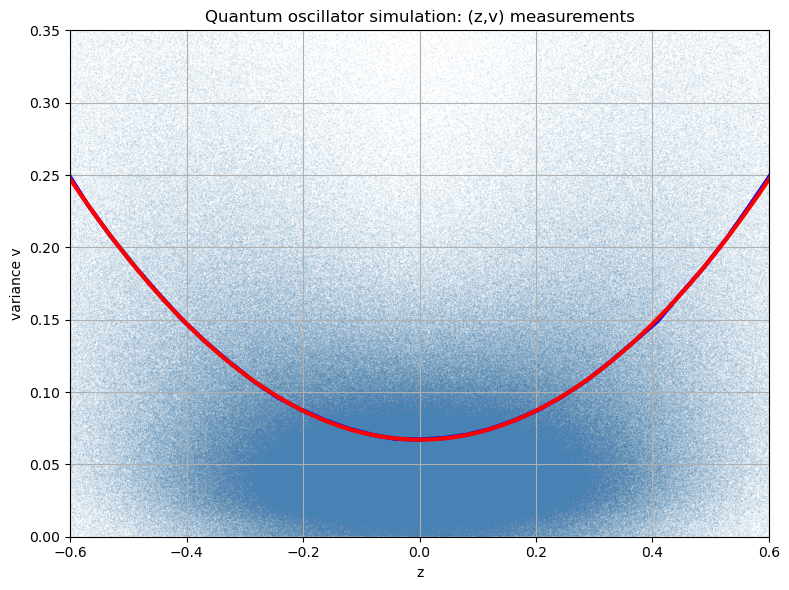

In [113]:
# ==========================================================
# Plot scatter
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    z_samples,
    v_samples,
    c="steelblue",
    s=0.6,
    alpha=0.1,
    edgecolor="none"
)


# binned mean curve

bins = np.linspace(
    -1,
    1,
    50
)

bin_centres = []
bin_means = []

for i in range(len(bins)-1):

    mask = (
        (z_samples>=bins[i]) &
        (z_samples<bins[i+1])
    )

    if np.sum(mask)>20:
        bin_centres.append(
            (bins[i]+bins[i+1])/2
        )
        bin_means.append(
            np.mean(v_samples[mask])
        )


plt.plot(
    bin_centres,
    bin_means,
    linewidth=3,
    c = "blue"
    #label="Conditional mean"
)


# q-variance prediction

z_grid = np.linspace(-1,1,300)

plt.plot(
    z_grid,
    sigma**2+z_grid**2/2,
    linewidth=3,
    c = "red",
    label=r"$E[v|z]=\sigma^2+z^2/2$"
)

plt.xlim(-0.6,0.6)
plt.ylim(0,0.35)
plt.xlabel("z")
plt.ylabel("variance v")

plt.title(
    "Quantum oscillator simulation: (z,v) measurements"
)

#plt.legend()
plt.grid(True)
plt.tight_layout()

print(np.std(v_samples)/np.mean(v_samples))



**Plot estimates of the quadratic coefficient**.

A naive approach to testing q-variance is to use standard linear regression to estimate the quadratic coefficient. As shown by the plot, this technique would appear to reject the hypothesis that the coefficient is 0.5, even though for the quantum model it holds by design. The problem is that standard regression techniques ignore things like heteroskedasticity. 

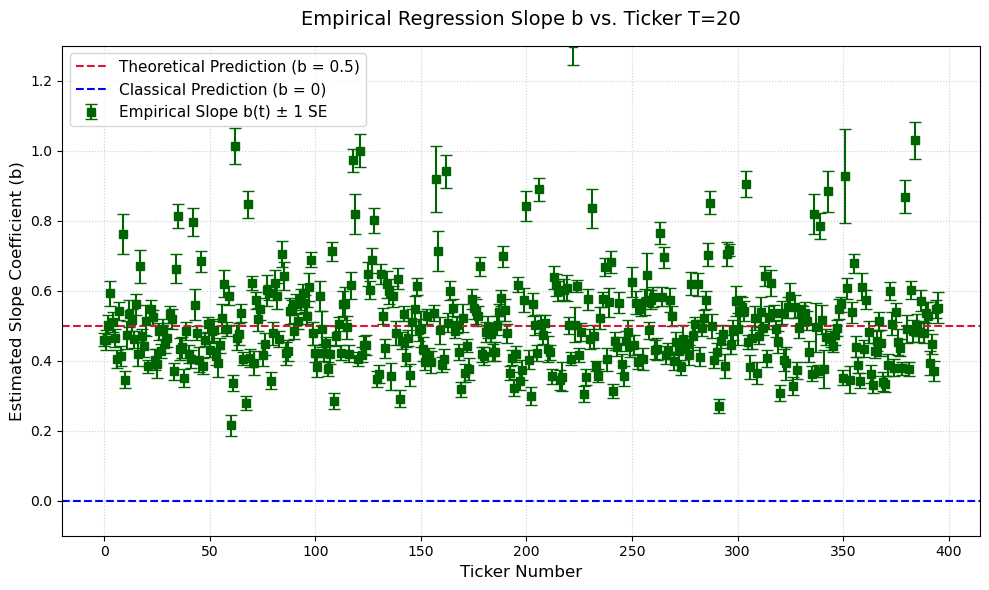

In [114]:
# now plot coef b vs ticker
import statsmodels.api as sm

def plot_slopes_stocks(dataframe):
    """
    Performs a linear regression y = a + b * z^2 for each period T,
    extracts the slope b(T), prints a summary table, and plots b(T) vs T.
    
    Parameters:
    - dataframe (pd.DataFrame): The master combined dataframe containing 'z', 'v', and 't'
    """
    # Group by the unique tickers present in the dataframe
    grouped = dataframe.groupby('tick')
    
    t_list = []
    b_list = []
    a_list = []
    slope_err_list = []
    
    for t_val, group in grouped:
        x = group['z']**2
        y = group['v']
        
        # np.polyfit(x, y, 1) fits a 1st-degree polynomial: y = slope * x + intercept
        # It handles ordinary least squares regression natively
        # slope, intercept = np.polyfit(x, y, 1)
        
        p, cov = np.polyfit(x, y, 1, cov=True)
        slope, intercept = p[0], p[1]

        # Extract standard errors from the diagonal of the covariance matrix
        # cov[0,0] corresponds to the variance of the slope
        slope_err = np.sqrt(cov[0, 0])
             
        t_list.append(t_val)
        b_list.append(slope)
        a_list.append(intercept)
        slope_err_list.append(slope_err)
        
        #print(f"{t_val:<12} | {intercept:<15.6f} | {slope:<15.4f} | {slope_err:<15.4f}")
        
        
    q_list = [0.5] * len(t_list)  # compare with constant 0.5

    # --- Visualization Code ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot empirical slope values
    ticker_numbers = np.arange(len(t_list))
    ax.errorbar(ticker_numbers, b_list, yerr=slope_err_list, fmt='s', markersize=6, 
                color='darkgreen', ecolor='darkgreen', elinewidth=1.5, capsize=4,
                linestyle='None', linewidth=2, label='Empirical Slope b(t) ± 1 SE')
    
    # Plot the expected theoretical horizontal line
    ax.axhline(y=0.5, color='crimson', linestyle='--', linewidth=1.5, 
               label='Theoretical Prediction (b = 0.5)')
    ax.axhline(y=0.0, color='blue', linestyle='--', linewidth=1.5, 
               label='Classical Prediction (b = 0)')
    
    # Visual Layout Polish
    ax.set_title(r'Empirical Regression Slope b vs. Ticker T=20', fontsize=14, pad=15)  #  for $|z|<0.6
    ax.set_xlabel('Ticker Number', fontsize=12)
    ax.set_ylabel(r'Estimated Slope Coefficient (b)', fontsize=12)
    
    # Configure grid lines and legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=11, loc='best')
    
    ax.set_ylim(-0.1, 1.3)
    
    plt.tight_layout()
    #plt.show()

# --- Execution ---
# select one period T=20 so data is not addected by correlations between sub-periods, which is an issue for real market data.

df2 = df[df["t"] == 20] 
plot_slopes_stocks(df2)

**Convergence test** 

A more robust test is adding random stocks to a portfolio, and comparing the fit of mean variance with the q-variance curve. Note that convergence still requires several stocks for the average portfolio, even though the model obeys q-variance by design. The reason is that testing q-variance involves fitting a quadratic to noisy data that is concentrated around the origin, so requires many points.

Starting simulation across M=20 random combinations...
Iteration 1/20 complete. Final R² = 0.9981
Iteration 2/20 complete. Final R² = 0.9966
Iteration 3/20 complete. Final R² = 0.9988
Iteration 4/20 complete. Final R² = 0.9985
Iteration 5/20 complete. Final R² = 0.9971
Iteration 6/20 complete. Final R² = 0.9980
Iteration 7/20 complete. Final R² = 0.9986
Iteration 8/20 complete. Final R² = 0.9971
Iteration 9/20 complete. Final R² = 0.9980
Iteration 10/20 complete. Final R² = 0.9967
Iteration 11/20 complete. Final R² = 0.9985
Iteration 12/20 complete. Final R² = 0.9991
Iteration 13/20 complete. Final R² = 0.9978
Iteration 14/20 complete. Final R² = 0.9963
Iteration 15/20 complete. Final R² = 0.9981
Iteration 16/20 complete. Final R² = 0.9967
Iteration 17/20 complete. Final R² = 0.9984
Iteration 18/20 complete. Final R² = 0.9993
Iteration 19/20 complete. Final R² = 0.9979
Iteration 20/20 complete. Final R² = 0.9990


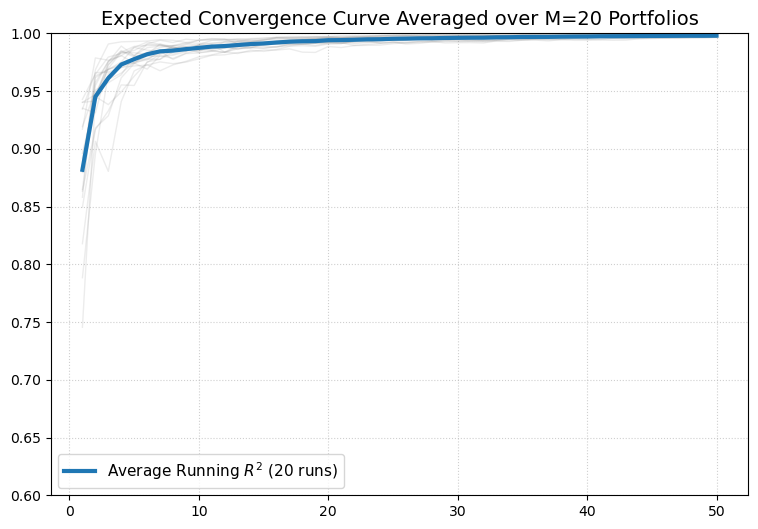

In [115]:
from scipy.optimize import curve_fit

def qvar(z, s0, zoff):    # define q-variance function, parameter is minimal volatility s0 and zoff
    return (s0**2 + (z - zoff)**2 / 2)

def get_random_50_r2_curve(dforig, tickers_pool, bins):
    """
    Selects 50 random tickers, builds the data-weighted aggregate 
    variance curve, and returns the running R^2 convergence array.
    """
    # Randomly sample 50 unique tickers
    selected_tickers = np.random.choice(tickers_pool, size=50, replace=False)
    df = dforig[dforig['tick'].isin(selected_tickers)].copy()

    # Setup tracking variables (expecting 50 stocks sequentially)
    n_tickers = 50
    r2_running = np.zeros(n_tickers)
    
    sum_var_curve = np.zeros(len(bins) - 1)
    sum_z_curve = np.zeros(len(bins) - 1)
    total_weights = np.zeros(len(bins) - 1)

    # Process sequentially to observe convergence over N_tick = 1 to 50
    for i, tickcur in enumerate(selected_tickers):
        dfcur = df[df["tick"] == tickcur].copy()
        
        binned = (dfcur.assign(z_bin=pd.cut(dfcur.z, bins=bins, include_lowest=True))
                  .groupby('z_bin', observed=False)
                  .agg(
                      z_sum=('z', 'sum'),
                      var_sum=('v', 'sum'),
                      bin_count=('v', 'count')
                  ))
        
        # Accumulate sums and counts
        sum_var_curve += np.nan_to_num(binned["var_sum"].values)
        sum_z_curve += np.nan_to_num(binned["z_sum"].values)
        total_weights += np.nan_to_num(binned["bin_count"].values)
        
        # True data-weighted averages at step i
        safe_weights = np.maximum(total_weights, 1)
        running_avg_var = sum_var_curve / safe_weights
        running_avg_z = sum_z_curve / safe_weights
        
        fit_mask = total_weights > 0
        fit_z = running_avg_z[fit_mask]
        fit_var = running_avg_var[fit_mask]
        
        if len(fit_z) > 2:
            try:
                popt, _ = curve_fit(qvar, fit_z, fit_var, p0=[0.26, 0])
                fitted = qvar(fit_z, popt[0], popt[1])
                
                ss_res = np.sum((fit_var - fitted) ** 2)
                ss_tot = np.sum((fit_var - fit_var.mean()) ** 2)
                r2_running[i] = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            except Exception:
                r2_running[i] = r2_running[i-1] if i > 0 else 0
        else:
            r2_running[i] = 0
            
    return r2_running


# --- RUNNING THE SIMULATION OVER M ITERATIONS ---
bins = np.arange(-1, 1.05, 0.05)   # 40 bins

M = 20  # Number of random portfolios to test
all_r2_curves = np.zeros((M, 50))  # Matrix to store every run
TICKERS1 = np.unique(df["tick"])

print(f"Starting simulation across M={M} random combinations...")
for m in range(M):
    # Call the function for iteration m
    all_r2_curves[m, :] = get_random_50_r2_curve(df, TICKERS1, bins)
    #     ndaypertick = 5*len(df[df['T'] == 5]) / df['ticker'].nunique()
    print(f"Iteration {m+1}/{M} complete. Final R² = {all_r2_curves[m, -1]:.4f}")

# Compute the global average curve across the M simulations
average_r2_curve = np.mean(all_r2_curves, axis=0)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(9, 6))
n_tick_axis = np.arange(1, 51)

# Plot individual iterations faintly to see the spread/variance
for m in range(M):
    ax.plot(n_tick_axis, all_r2_curves[m, :], color='gray', alpha=0.15, lw=1)

# Plot the strong aggregated average curve
ax.plot(n_tick_axis, average_r2_curve, '-', color='tab:blue', lw=3, label=f'Average Running $R^2$ ({M} runs)')
#ax.axhline(0.999, color='tab:red', linestyle='--', alpha=0.7, label='Target Convergence (0.999)')
ax.set_ylim(0.6, 1)

#ax.set_xlabel('Number of Tickers Mixed ($N_{tick}$)', fontsize=12)
#ax.set_ylabel('$R^2$ Score', fontsize=12)
ax.set_title(f'Expected Convergence Curve Averaged over M={M} Portfolios', fontsize=14)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=11)
#plt.savefig('ConvergeCheckSP.png', dpi=300, bbox_inches='tight')

plt.show()


**Plot distributions of V for different binned values of z**

Bin (-1.0, -0.9]: Coefficient of Variation = 0.9901, Mean = 0.5148, Std = 0.5096
Bin (-0.9, -0.7]: Coefficient of Variation = 1.0353, Mean = 0.3737, Std = 0.3868
Bin (-0.7, -0.5]: Coefficient of Variation = 1.0887, Mean = 0.2408, Std = 0.2622
Bin (-0.5, -0.3]: Coefficient of Variation = 1.1280, Mean = 0.1436, Std = 0.1620
Bin (-0.3, -0.1]: Coefficient of Variation = 1.0713, Mean = 0.0871, Std = 0.0933
Bin (-0.1, 0.1]: Coefficient of Variation = 0.9126, Mean = 0.0687, Std = 0.0627
Bin (0.1, 0.3]: Coefficient of Variation = 1.0581, Mean = 0.0871, Std = 0.0921
Bin (0.3, 0.5]: Coefficient of Variation = 1.1276, Mean = 0.1433, Std = 0.1616
Bin (0.5, 0.7]: Coefficient of Variation = 1.1016, Mean = 0.2410, Std = 0.2654
Bin (0.7, 0.9]: Coefficient of Variation = 1.0123, Mean = 0.3760, Std = 0.3807


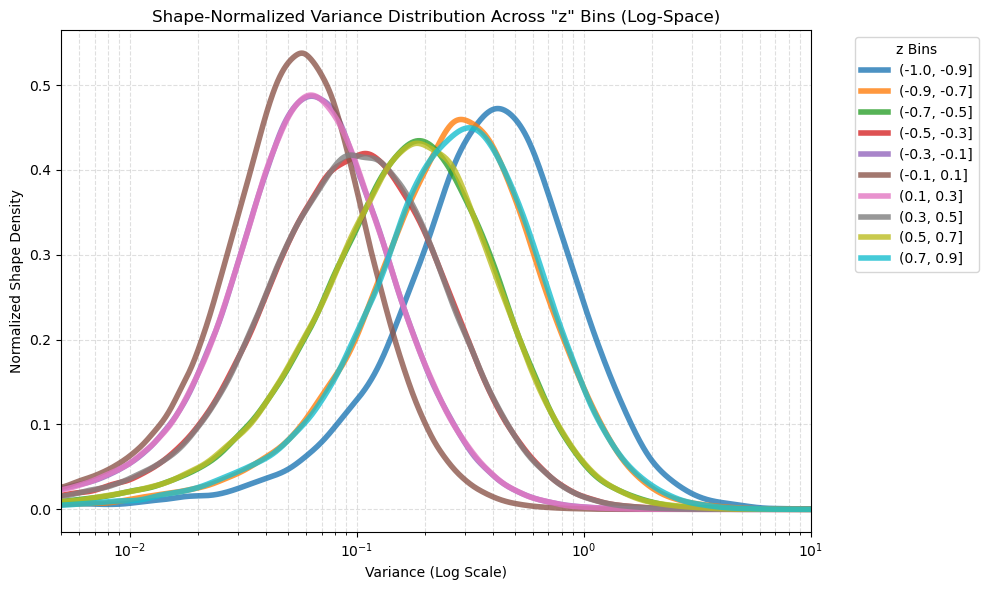

In [116]:
from scipy.stats import gaussian_kde
def analyze_variance_by_bin2(df):
    # 1. Define custom edges to handle z values from -1.0 to 1.0
    bin_edges = [-1.0001] + list(np.arange(-0.9, 1.01, 0.1*2))
    
    # 2. Bin the 'z' column
    df = df.copy()
    df['z_bin'] = pd.cut(df['z'], bins=bin_edges)
    
    # 3. Initialize the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 4. Generate high-resolution log-evaluation grid to match your limits [5e-3, 10]
    # We evaluate directly in natural log space
    x_min, x_max = 5e-3, 10
    log_grid = np.linspace(np.log(x_min), np.log(x_max), num=1000)
    
    # 5. Process each bin sequentially
    for bin_interval, group in df.groupby('z_bin', observed=False):
        # Drop missing values and filter out non-positive values (cannot log 0 or negatives)
        var_data = group['v'].dropna()
        var_data = var_data[var_data > 0]
        
        if var_data.empty:
            continue
            
        # 6. Calculate Coefficient of Variation (CV = SD / Mean) on original data
        mean_val = var_data.mean()
        std_val = var_data.std()
        cv = std_val / mean_val
        print(f"Bin {bin_interval}: Coefficient of Variation = {cv:.4f}, Mean = {mean_val:.4f}, Std = {std_val:.4f}")
            
        # 7. LOG NORMALIZATION: Transform data to log-space to isolate shape 
        log_data = np.log(var_data)
        
        # Build a kernel density estimator in log-space
        # Handling edge cases where a bin might only have 1 distinct value
        try:
            kde = gaussian_kde(log_data)
            density_values = kde(log_grid)
        except np.linalg.LinAlgError:
            continue # Skip bins with zero variance in log-space
        
        # 8. Plot the normalized curves
        # np.exp(log_grid) maps the log evaluation points back to your 5e-3 to 10 scale
        ax.plot(
            np.exp(log_grid), 
            density_values, 
            label=str(bin_interval), 
            alpha=0.8, 
            linewidth=4
        )
    
    # 9. Finalize plot layout and labels
    ax.set_xscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_title('Shape-Normalized Variance Distribution Across "z" Bins (Log-Space)')
    ax.set_xlabel('Variance (Log Scale)')
    ax.set_ylabel('Normalized Shape Density')
    ax.legend(title='z Bins', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()

analyze_variance_by_bin2(df)

**Now plot CV(T) versus T over all data**

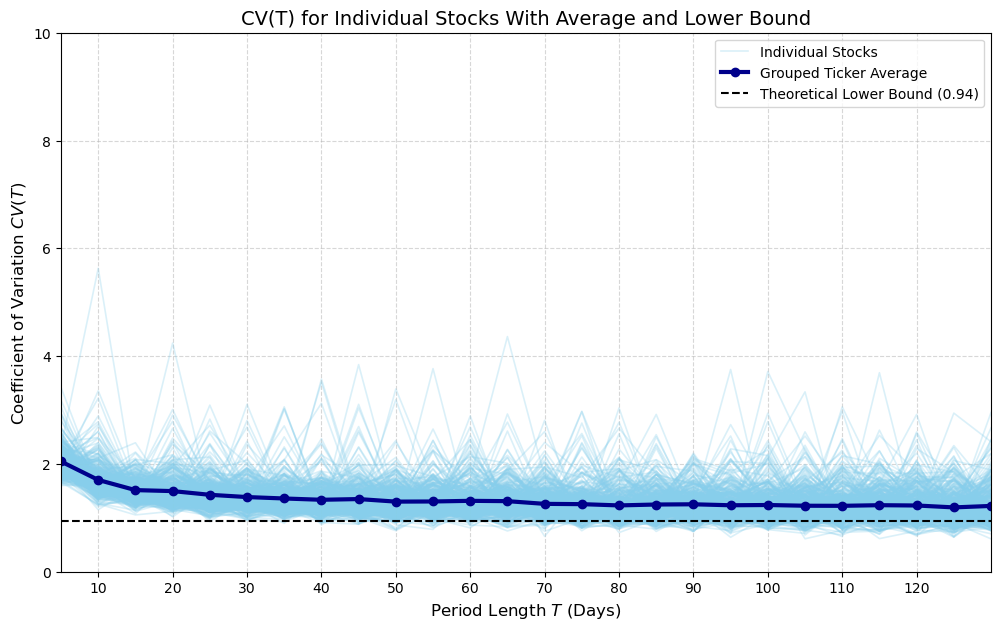

In [117]:
def plot_cv_vs_period_comprehensive(dataframe):
    """Calculates and plots CV(T) versus T using three methods to expose pooling bias:

    1. Individual stock curves (Light Blue)
    2. Grouped-then-Averaged CV across tickers (Dark Blue)
    3. Unfiltered pooled calculation across all points natively (Orange)
    """
    # Verify required columns exist
    required_cols = {"t", "v", "tick"}
    if not required_cols.issubset(dataframe.columns):
        missing = required_cols - set(dataframe.columns)
        print(f"Error: Dataframe is missing columns: {missing}")
        return

    plt.figure(figsize=(12, 7))

    # 1. Plot individual ticker curves in the background
    tickers = dataframe["tick"].unique()
    first_ticker = True

    # Dictionary to store each ticker's CV series to calculate the true average line
    ticker_cvs = {}

    for ticker in tickers:
        ticker_df = dataframe[dataframe["tick"] == ticker]

        t_stats = ticker_df.groupby("t")["v"].agg(["std", "mean"])
        t_stats["CV"] = t_stats["std"] / t_stats["mean"]
        t_stats = t_stats.sort_index()

        # Save for our cross-ticker average calculation later
        ticker_cvs[ticker] = t_stats["CV"]

        label = "Individual Stocks" if first_ticker else ""
        plt.plot(
            t_stats.index,
            t_stats["CV"],
            color="skyblue",
            alpha=0.3,
            linewidth=1.2,
            label=label,
        )
        first_ticker = False

    # 2. Calculate the Grouped Aggregate Line
    # (Average of individual ticker CV curves at each T)
    df_cv_all = pd.DataFrame(ticker_cvs)
    grouped_avg_cv = df_cv_all.mean(axis=1)

    plt.plot(
        grouped_avg_cv.index,
        grouped_avg_cv.values,
        marker="o",
        linewidth=3,
        color="darkblue",
        markersize=6,
        label="Grouped Ticker Average",
    )

    # 3. Calculate the Unfiltered (Pooled) Aggregate Line
    # (Treating all data rows together as a single dataset)
    unfiltered_stats = dataframe.groupby("t")["v"].agg(["std", "mean"])
    unfiltered_stats["CV"] = unfiltered_stats["std"] / unfiltered_stats["mean"]
    unfiltered_stats = unfiltered_stats.sort_index()

    # plt.plot(unfiltered_stats.index,unfiltered_stats["CV"],marker="s",linewidth=3,color="darkorange", linestyle="--",markersize=6,label="Unfiltered Pooled Data Average")

    plt.axhline(y=0.94, color="black", linestyle="--", linewidth=1.5, label="Theoretical Lower Bound (0.94)")

    # 4. Formatting and styling
    # plt.yscale("log")
    plt.title(
        "CV(T) for Individual Stocks With Average and Lower Bound",
        fontsize=14,
    )
    plt.xlabel("Period Length $T$ (Days)", fontsize=12)
    plt.ylabel("Coefficient of Variation $CV(T)$", fontsize=12)

    plt.xticks(np.arange(0, 130, step=10))
    plt.xlim(5, 130)
    plt.ylim(0, 10)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper right", frameon=True, facecolor="white")


plot_cv_vs_period_comprehensive(df)
